# Multi-Factor Quant Trading System
Medium-term US equity strategy with backtesting

In [48]:
# Setup: clone repo and install dependencies
!git clone -b claude/quant-trading-system-NQvPT https://github.com/yingwang/trade.git
%cd trade
!pip install -q -r requirements.txt

Cloning into 'trade'...
remote: Enumerating objects: 59, done.
remote: Counting objects: 100% (59/59), done.
remote: Compressing objects: 100% (46/46), done.
remote: Total 59 (delta 15), reused 50 (delta 11), pack-reused 0 (from 0)
Receiving objects: 100% (59/59), 36.93 KiB | 787.00 KiB/s, done.
Resolving deltas: 100% (15/15), done.
/content/trade/trade/trade/trade/trade/trade/trade


In [49]:
import logging
logging.basicConfig(level=logging.INFO, format='%(asctime)s [%(levelname)s] %(name)s: %(message)s')

from quant.utils.config import load_config
from quant.strategy import MultiFactorStrategy
from quant.backtest.report import monthly_returns_table, risk_report

In [50]:
# Load config and run backtest
config = load_config('config.yaml')
strategy = MultiFactorStrategy(config)
result = strategy.run_backtest()
print(result.summary())

BACKTEST RESULTS
  Total Return                  :       1.3573
  CAGR                          :       0.2290
  Annualized Volatility         :       0.1496
  Sharpe Ratio                  :       1.5306
  Sortino Ratio                 :       2.0224
  Calmar Ratio                  :       1.0616
  Max Drawdown                  :      -0.2157
  Win Rate (daily)              :       0.4466
  Avg Rebalance Turnover        :       0.7453
  Information Ratio             :       0.7880
  Benchmark Return              :       0.4986
  Num Trades                    :           40


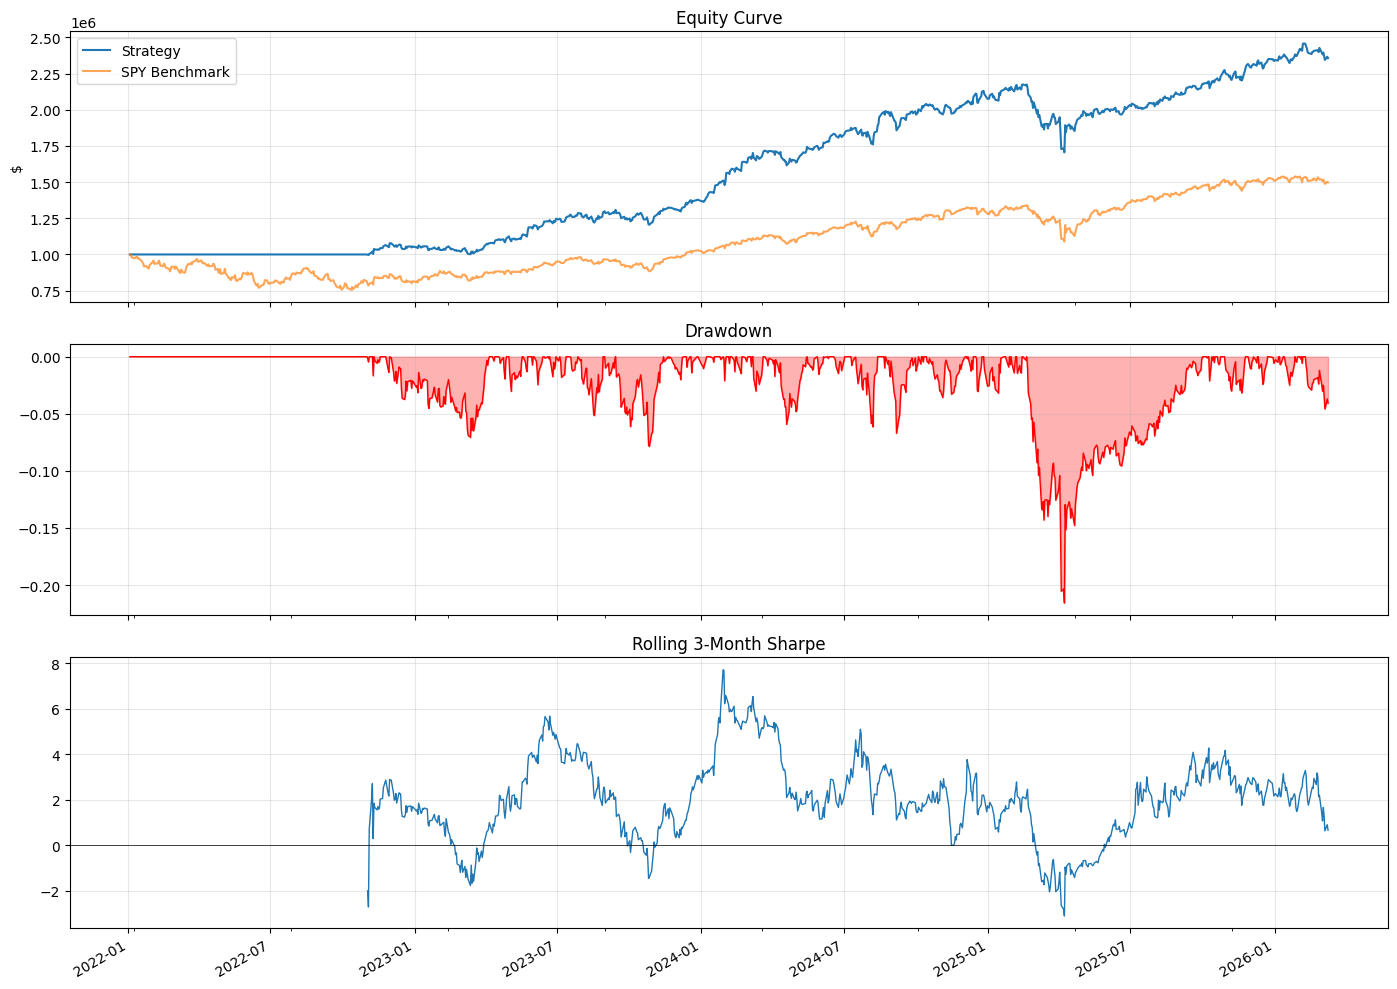

In [51]:
# Equity curve vs benchmark
import matplotlib.pyplot as plt

fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)

ax = axes[0]
result.equity_curve.plot(ax=ax, label='Strategy', linewidth=1.5)
result.benchmark_curve.plot(ax=ax, label='SPY Benchmark', linewidth=1.5, alpha=0.7)
ax.set_title('Equity Curve'); ax.set_ylabel('$'); ax.legend(); ax.grid(True, alpha=0.3)

ax = axes[1]
dd = (result.equity_curve - result.equity_curve.cummax()) / result.equity_curve.cummax()
dd.plot(ax=ax, color='red', linewidth=1)
ax.fill_between(dd.index, dd.values, 0, alpha=0.3, color='red')
ax.set_title('Drawdown'); ax.grid(True, alpha=0.3)

ax = axes[2]
rolling_sharpe = (result.returns.rolling(63).mean() * 252) / (result.returns.rolling(63).std() * 252**0.5)
rolling_sharpe.plot(ax=ax, linewidth=1)
ax.axhline(0, color='black', linewidth=0.5)
ax.set_title('Rolling 3-Month Sharpe'); ax.grid(True, alpha=0.3)

plt.tight_layout(); plt.show()

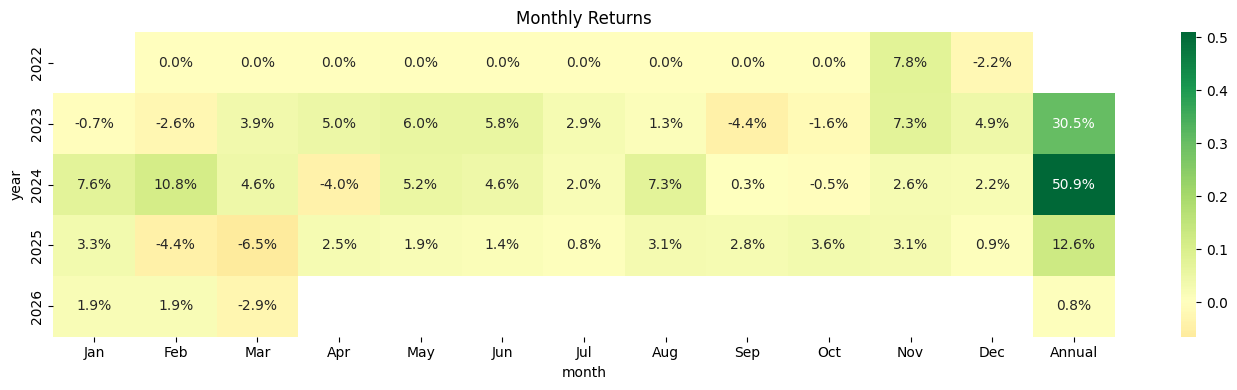

month,Jan,Feb,Mar,Apr,May,Jun,Jul,Aug,Sep,Oct,Nov,Dec,Annual
year,,,,,,,,,,,,,
2022,NaN,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.077771,-0.021888,NaN
2023,-0.006583,-0.026038,0.038697,0.049953,0.059754,0.057523,0.028819,0.012568,-0.043732,-0.016233,0.073468,0.048786,0.304783
2024,0.075512,0.108229,0.046223,-0.040015,0.051896,0.046111,0.020219,0.073140,0.002656,-0.004668,0.026225,0.021792,0.509243
2025,0.033494,-0.044285,-0.064941,0.024898,0.019363,0.014322,0.008212,0.030740,0.027793,0.035809,0.030714,0.008914,0.126004
2026,0.019300,0.019048,-0.029129,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.008459


In [52]:
# Monthly returns heatmap
import seaborn as sns

monthly = monthly_returns_table(result.equity_curve)
fig, ax = plt.subplots(figsize=(14, 4))
sns.heatmap(monthly, annot=True, fmt='.1%', cmap='RdYlGn', center=0, ax=ax)
ax.set_title('Monthly Returns'); plt.tight_layout(); plt.show()
monthly

In [53]:
# Risk report
import pandas as pd
risk = risk_report(result.returns)
pd.Series(risk, name='Value')

,Value
Daily Mean,0.000863
Daily Std,0.009425
Skewness,1.087338
Kurtosis,20.974680
Best Day,0.109887
Worst Day,-0.064570
VaR 95%,-0.012617
CVaR 95%,-0.020250
Positive Days %,0.446565
Avg Win / Avg Loss,1.064640


In [54]:
# Current live signals (raw alpha scores)
signals = strategy.get_current_signal()
print("=== Raw Alpha Scores (top 20) ===")
signals.head(20)

=== Raw Alpha Scores (top 20) ===


,2026-03-10
Ticker,
MRK,1.263142
JNJ,0.917095
XOM,0.870421
GOOGL,0.855962
PEP,0.550567
LLY,0.464185
KO,0.452583
JPM,0.410837
WMT,0.391569


In [56]:
# ============================================================
# TARGET PORTFOLIO - What to buy today
# ============================================================
# Reload to pick up latest code changes
import importlib, quant.strategy
importlib.reload(quant.strategy)
from quant.strategy import MultiFactorStrategy
strategy = MultiFactorStrategy(load_config('config.yaml'))

# Change capital to your actual account size
MY_CAPITAL = 100_000  # <-- EDIT THIS to your portfolio size in USD

portfolio = strategy.get_current_portfolio(capital=MY_CAPITAL)

print(f"{'='*65}")
print(f"  TARGET PORTFOLIO  |  Capital: ${MY_CAPITAL:,.0f}")
print(f"{'='*65}")
print(f"  {'Stock':<8} {'Weight':>8} {'Dollars':>10} {'Shares':>8} {'Price':>10} {'Score':>8}")
print(f"  {'-'*60}")
for sym, row in portfolio.iterrows():
    print(f"  {sym:<8} {row['weight_pct']:>7.1f}% ${row['dollars']:>9,.0f} {row['shares']:>7d}  ${row['price']:>8.2f} {row['score']:>8.3f}")
print(f"  {'-'*60}")
print(f"  {'TOTAL':<8} {portfolio['weight_pct'].sum():>7.1f}% ${portfolio['dollars'].sum():>9,.0f}")
print(f"  Cash reserve: ${MY_CAPITAL - portfolio['dollars'].sum():,.0f}")
print(f"{'='*65}")

portfolio

AttributeError: 'MultiFactorStrategy' object has no attribute 'get_current_portfolio'